# Project GEO876 - Wildfire Mapping, Test Notebook
Janis Büchel

This Notebook is just to try the predefined code

In [ ]:
# Let's set your map key that was emailed to you. It should look something like 'abcdef1234567890abcdef1234567890'
MAP_KEY = 'e5b967caf968ec1283cb213a30e9b9d4'
# MAP_KEY = 'e5b967caf968ec1283cb213a30e9b9d4'

# now let's check how many transactions we have
import pandas as pd
import requests
url = 'https://firms.modaps.eosdis.nasa.gov/mapserver/mapkey_status/?MAP_KEY=' + MAP_KEY
try:
  response = requests.get(url)
  data = response.json()
  df = pd.Series(data)
  display(df)
except:
  # possible error, wrong MAP_KEY value, check for extra quotes, missing letters
  print ("There is an issue with the query. \nTry in your browser: %s" % url)

transaction_limit             5000
current_transactions             6
transaction_interval    10 minutes
dtype: object

In [ ]:
# let's create a simple function that tells us how many transactions we have used.
# We will use this in later examples

def get_transaction_count() :
  count = 0
  try:
    response = requests.get(url)
    data = response.json()
    df = pd.Series(data)
    count = df['current_transactions']
  except:
    print ("Error in our call.")
  return count

tcount = get_transaction_count()
print ('Our current transaction count is %i' % tcount)

Our current transaction count is 6


In [5]:
# let's query data_availability to find out what date range is available for various datasets
# we will explain these datasets a bit later

# this url will return information about all supported sensors and their corresponding datasets
# instead of 'all' you can specify individual sensor, ex:LANDSAT_NRT
da_url = 'https://firms.modaps.eosdis.nasa.gov/api/data_availability/csv/' + MAP_KEY + '/all'
df = pd.read_csv(da_url)
display(df)

,data_id,min_date,max_date
0,MODIS_NRT,2026-01-01,2026-05-02
1,MODIS_SP,2000-11-01,2025-12-31
2,VIIRS_NOAA20_NRT,2026-03-01,2026-05-02
3,VIIRS_NOAA20_SP,2018-04-01,2026-02-28
4,VIIRS_NOAA21_NRT,2024-01-17,2026-05-02
5,VIIRS_SNPP_NRT,2026-03-01,2026-05-02
6,VIIRS_SNPP_SP,2012-01-20,2026-02-28
7,LANDSAT_NRT,2022-06-20,2026-05-01
8,GOES_NRT,2022-08-09,2026-05-02
9,BA_MODIS,2000-11-01,2026-02-01


In [6]:
# now let's see how many transactions we use by querying this end point

start_count = get_transaction_count()
pd.read_csv(da_url)
end_count = get_transaction_count()
print ('We used %i transactions.' % (end_count-start_count))

# now remember, after 10 minutes this will reset

We used 5 transactions.


In [7]:
# in this example let's look at VIIRS NOAA-20, entire world and the most recent day
area_url = 'https://firms.modaps.eosdis.nasa.gov/api/area/csv/' + MAP_KEY + '/VIIRS_NOAA20_NRT/world/1'
start_count = get_transaction_count()
df_area = pd.read_csv(area_url)
end_count = get_transaction_count()
print ('We used %i transactions.' % (end_count-start_count))

df_area

We used 36 transactions.


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
0,43.23402,27.59361,301.68,0.41,0.37,2026-05-02,1,N20,VIIRS,n,2.0NRT,275.94,0.65,N
1,44.08171,22.10381,300.65,0.45,0.47,2026-05-02,1,N20,VIIRS,n,2.0NRT,277.19,1.23,N
2,44.23989,28.31005,299.15,0.40,0.37,2026-05-02,1,N20,VIIRS,n,2.0NRT,276.42,0.79,N
3,44.77201,33.86320,309.63,0.43,0.38,2026-05-02,1,N20,VIIRS,n,2.0NRT,275.44,1.40,N
4,44.83135,20.69478,306.45,0.53,0.50,2026-05-02,1,N20,VIIRS,n,2.0NRT,275.75,2.16,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9589,19.41220,-155.27684,327.55,0.40,0.40,2026-05-02,1158,N20,VIIRS,n,2.1URT,303.61,3.11,N
9590,19.41276,-155.28049,330.69,0.40,0.40,2026-05-02,1158,N20,VIIRS,n,2.1URT,305.48,3.11,N
9591,19.41332,-155.28413,325.71,0.40,0.40,2026-05-02,1158,N20,VIIRS,n,2.1URT,303.54,2.56,N
9592,19.41388,-155.28778,308.06,0.40,0.40,2026-05-02,1158,N20,VIIRS,n,2.1URT,293.09,2.56,N


In [8]:
# We can also focus on a smaller area ex. South Asia and get the last 3 days of records
area_url = 'https://firms.modaps.eosdis.nasa.gov/api/area/csv/' + MAP_KEY + '/VIIRS_NOAA20_NRT/54,5.5,102,40/3'
df_area = pd.read_csv(area_url)
df_area

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
0,5.64697,100.75797,335.49,0.41,0.37,2026-04-30,648,N20,VIIRS,n,2.0NRT,295.91,3.19,D
1,5.67710,100.76804,331.07,0.41,0.37,2026-04-30,648,N20,VIIRS,n,2.0NRT,297.40,2.64,D
2,5.79597,100.72046,332.45,0.41,0.37,2026-04-30,648,N20,VIIRS,n,2.0NRT,296.49,2.23,D
3,5.86695,100.53847,334.14,0.40,0.37,2026-04-30,648,N20,VIIRS,n,2.0NRT,287.36,3.98,D
4,6.20443,101.99571,330.10,0.46,0.39,2026-04-30,648,N20,VIIRS,n,2.0NRT,277.61,6.25,D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14149,38.68140,54.31885,335.89,0.51,0.41,2026-05-02,941,N20,VIIRS,n,2.0NRT,294.16,2.43,D
14150,36.50238,54.93309,336.06,0.51,0.41,2026-05-02,943,N20,VIIRS,l,2.0NRT,306.55,4.60,D
14151,37.03158,62.42290,335.12,0.44,0.62,2026-05-02,943,N20,VIIRS,n,2.0NRT,295.39,1.65,D
14152,37.11610,62.36419,347.94,0.43,0.62,2026-05-02,943,N20,VIIRS,n,2.0NRT,298.60,19.46,D


In [9]:
# import libraries for data manipulation

import pandas as pd

# Let's read VIIRS csv sample data set into a DataFrame df

df = pd.read_csv('https://firms.modaps.eosdis.nasa.gov/content/notebooks/sample_viirs_snpp_071223.csv')

# show how many rows (records) and columns (values per record) we have

print ('FIRMS sample fire data contains %i rows and %i columns' % (df.shape[0], df.shape[1]))
df.shape

print(df.head())

print(df.tail())

FIRMS sample fire data contains 74605 rows and 14 columns
   latitude  longitude  bright_ti4  scan  track    acq_date  acq_time  \
0   0.05836   29.59085      295.64  0.38   0.59  2023-07-12         3   
1   0.48765   31.50760      296.73  0.51   0.66  2023-07-12         3   
2   2.15227   13.94524      305.26  0.51   0.49  2023-07-12         3   
3   2.15681   13.94618      319.05  0.51   0.49  2023-07-12         3   
4   2.15754   13.94131      301.13  0.51   0.50  2023-07-12         3   

  satellite instrument confidence version  bright_ti5   frp daynight  
0         N      VIIRS          n  2.0NRT      275.15  0.83        N  
1         N      VIIRS          n  2.0NRT      275.15  0.56        N  
2         N      VIIRS          n  2.0NRT      287.94  1.08        N  
3         N      VIIRS          n  2.0NRT      288.77  1.81        N  
4         N      VIIRS          n  2.0NRT      288.17  1.81        N  
       latitude  longitude  bright_ti4  scan  track    acq_date  acq_time  \


In [10]:
import pandas as pd
df = pd.read_csv('https://firms.modaps.eosdis.nasa.gov/content/notebooks/sample_viirs_snpp_071223.csv')

# From 'Regional Coordinates' we can get Canada's approximate bounding box
# Canada coordinates: West South, East North as -150 40, -49 79

# copy() - will create a duplicate dataset with Canada data only
df_canada = df[(df['longitude'] >= -150) & (df['latitude'] >= 40) & (df['longitude'] <= -49) & (df['latitude'] <= 79)].copy()
print ('Canada subset contains %i records.' % len(df_canada))

Canada subset contains 14045 records.


In [11]:
# Let's also create another one for Australia and New Zealand for our later example
# Australia and New Zealand coordinates: West South, East North as 110 -55, 180 -10

# alternatively, we can assign extent values into an array
extent = [110, -55, 180, -10]
df_aus_nz = df[(df['longitude'] >= extent[0]) & (df['latitude'] >= extent[1]) & (df['longitude'] <= extent[2]) & (df['latitude'] <= extent[3])].copy()
print ('Australia and New Zealand subset contains %i records.' % len(df_aus_nz))

Australia and New Zealand subset contains 2999 records.


In [12]:
# Let's subset our data to values with confidence normal 'n' and high 'h'
# and fire radiative power (frp) higher or equal to 5

df_custom_day = df[((df['confidence'] == 'n') | (df['confidence'] == 'h')) & (df['frp'] >= 5) & (df['daynight'] == 'D')]
print ('Day time detection with normal and high confidence and frp > 5 contains %i records' %  len(df_custom_day))

# the same as above but with night detections

df_custom_night = df[((df['confidence'] == 'n') | (df['confidence'] == 'h')) & (df['frp'] >= 5) & (df['daynight'] == 'N')]
print ('Night time detections with normal and high confidence and frp > 5 contains %i records' %  len(df_custom_night))

Day time detection with normal and high confidence and frp > 5 contains 35504 records
Night time detections with normal and high confidence and frp > 5 contains 2683 records


In [13]:
# reload just in case steps were missed
import pandas as pd
df = pd.read_csv('https://firms.modaps.eosdis.nasa.gov/content/notebooks/sample_viirs_snpp_071223.csv')
df_canada = df[(df['longitude'] >= -150) & (df['latitude'] >= 40) & (df['longitude'] <= -49) & (df['latitude'] <= 79)].copy()
df_aus_nz = df[(df['longitude'] >= 110) & (df['latitude'] >= -55) & (df['longitude'] <= 180) & (df['latitude'] <=-10)].copy()


# let's create datetime column in our dataset combining acq_date and acq_time

df_canada['acq_datetime'] = pd.to_datetime(df_canada['acq_date'] + ' ' + df_canada['acq_time'].astype(str).str.zfill(4), format='%Y-%m-%d %H%M')

# view random 5 records to confirm our conversion.
# note: seconds are set to 0; as our dataset doesn't provide information about seconds

print ('Canada sample datetime info:')
df_canada['acq_datetime'].sample(5)

Canada sample datetime info:


21604   2023-07-12 09:58:00
25737   2023-07-12 10:00:00
73502   2023-07-12 19:50:00
25876   2023-07-12 10:00:00
23755   2023-07-12 09:58:00
Name: acq_datetime, dtype: datetime64[us]

In [14]:
# Now let's see the minimum and maximum datetime range available for Canada

print ('Canada datetime value range: %s to %s' % (str(df_canada['acq_datetime'].min()), str(df_canada['acq_datetime'].max())))

Canada datetime value range: 2023-07-12 04:53:00 to 2023-07-12 19:50:00


In [1]:
import geopandas
import matplotlib.pyplot as plt
from cartopy import crs as ccrs
from geodatasets import get_path

c:\Users\janis\miniconda\envs\project_geo876\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Axes: >

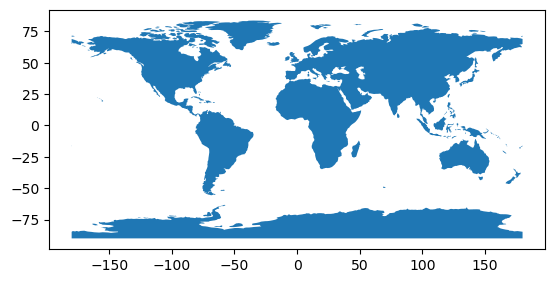

In [2]:
# let's get our basic earth data

path = get_path("naturalearth.land")
world = geopandas.read_file(path)

# and test our libraries loaded

world.plot()


<GeoAxes: title={'center': 'EPSG:3857'}>

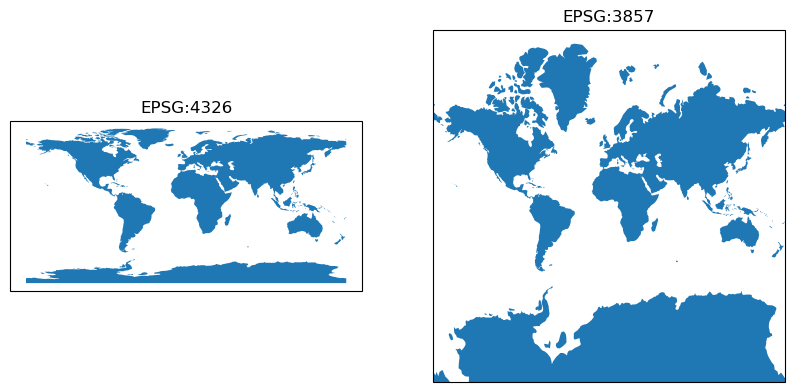

In [3]:
crs = ccrs.epsg("3857")
world_epsg = world.to_crs(epsg="3857")

fig, axs = plt.subplots(1, 2, subplot_kw={"projection": crs}, figsize=(10, 5))
axs[0].set(title='EPSG:4326')
axs[1].set(title='EPSG:3857')
world.plot(ax=axs[0])
world_epsg.plot(ax=axs[1])

In [4]:
import pandas as pd
df = pd.read_csv('https://firms.modaps.eosdis.nasa.gov/content/notebooks/sample_viirs_snpp_071223.csv')

# show top 5 records
df.head()

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
0,0.05836,29.59085,295.64,0.38,0.59,2023-07-12,3,N,VIIRS,n,2.0NRT,275.15,0.83,N
1,0.48765,31.50760,296.73,0.51,0.66,2023-07-12,3,N,VIIRS,n,2.0NRT,275.15,0.56,N
2,2.15227,13.94524,305.26,0.51,0.49,2023-07-12,3,N,VIIRS,n,2.0NRT,287.94,1.08,N
3,2.15681,13.94618,319.05,0.51,0.49,2023-07-12,3,N,VIIRS,n,2.0NRT,288.77,1.81,N
4,2.15754,13.94131,301.13,0.51,0.50,2023-07-12,3,N,VIIRS,n,2.0NRT,288.17,1.81,N


In [5]:
# now convert latitude, longitude values into point geometry

gdf = geopandas.GeoDataFrame(
    df, geometry=geopandas.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326"
)

# show top 3 records
gdf.head(3)

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,geometry
0,0.05836,29.59085,295.64,0.38,0.59,2023-07-12,3,N,VIIRS,n,2.0NRT,275.15,0.83,N,POINT (29.59085 0.05836)
1,0.48765,31.50760,296.73,0.51,0.66,2023-07-12,3,N,VIIRS,n,2.0NRT,275.15,0.56,N,POINT (31.5076 0.48765)
2,2.15227,13.94524,305.26,0.51,0.49,2023-07-12,3,N,VIIRS,n,2.0NRT,287.94,1.08,N,POINT (13.94524 2.15227)


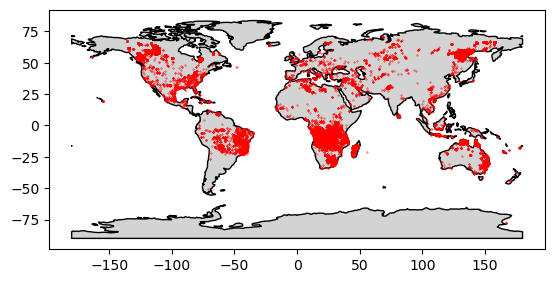

In [6]:
ax = world.plot(color="lightgrey", edgecolor="black")

# We can now plot our ``GeoDataFrame``.
gdf.plot(ax=ax, color="red", markersize=0.1)

plt.show()

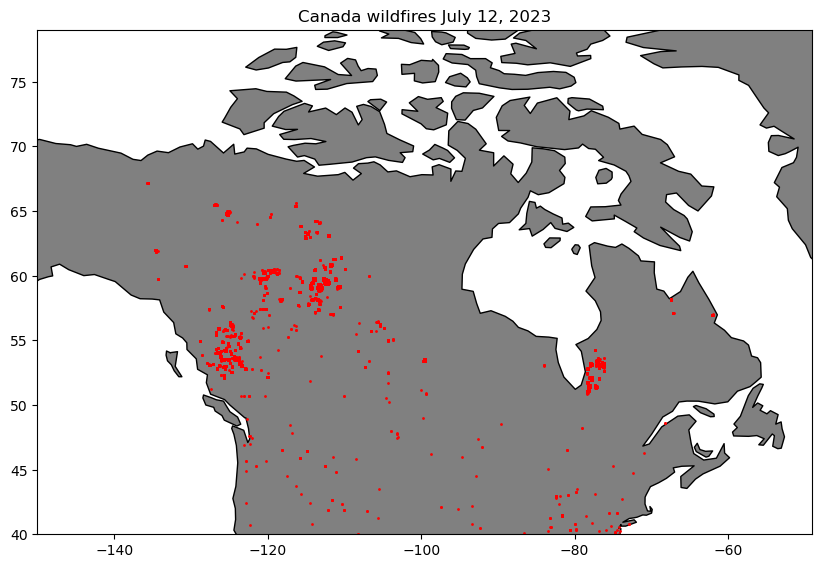

In [7]:
df_canada = df[(df['longitude'] >= -150) & (df['latitude'] >= 40) & (df['longitude'] <= -49) & (df['latitude'] <= 79)].copy()

# create geometry for points using latitude and longitude and specifying projection as EPSG:4326

gdf = geopandas.GeoDataFrame(
    df_canada, geometry=geopandas.points_from_xy(df_canada.longitude, df_canada.latitude), crs="EPSG:4326"
)

# set our extent
extent = [-150, 40, -49, 79]
ax = world.plot(figsize=(10, 10), color="grey", edgecolor="black")
ax.set_xlim([extent[0],  extent[2]])
ax.set_ylim([extent[1],  extent[3]])

ax.set(title='Canada wildfires July 12, 2023')

# We can now plot our ``GeoDataFrame``.
gdf.plot(ax=ax, color="red", markersize=1)

plt.show()